## Phase 4 — MLOps Pipeline + Drift Detection

### The production problem

A model trained today may degrade tomorrow.  In time-series anomaly detection,
**data drift** occurs when the underlying signal distribution shifts — the
machine starts behaving differently, the sensor ages, or the operating
conditions change.  Classical retraining triggers (scheduled retraining,
accuracy drop alerts) are reactive and slow.

This phase introduces a **proactive, topology-aware drift detector** that
catches distribution shift *before* model performance degrades.

---

### Topological Wasserstein Drift Detection

The core idea: if the signal distribution shifts, the **persistence diagrams**
of new windows will differ from those of the reference (training) windows.
We measure this difference using the **Wasserstein distance**:

$$
W_p(\mathcal{D}_1, \mathcal{D}_2) =
\left(
  \inf_{\gamma : \mathcal{D}_1 \to \mathcal{D}_2}
  \sum_{x \in \mathcal{D}_1} \|x - \gamma(x)\|^p
\right)^{1/p}
$$

where $\gamma$ ranges over all bijections between the two diagrams
(including the diagonal — points can be matched to their projection).

**Why this is better than classical drift detectors:**

| Detector | Operates on | Detects |
|---|---|---|
| KS test | Raw feature values | Marginal distribution shift |
| PSI | Binned distributions | Covariate shift |
| ADWIN | Scalar error stream | Concept drift |
| **TopologicalDriftDetector** | **Persistence diagrams** | **Attractor shape shift** |

The Wasserstein distance on persistence diagrams is **mathematically
principled** — the stability theorem (Cohen-Steiner et al., 2007) guarantees:

$$
W_\infty(\mathcal{D}(f), \mathcal{D}(g)) \leq \|f - g\|_\infty
$$

Small signal perturbations → small Wasserstein distance → no false drift
alerts.  Large structural changes → large Wasserstein distance → drift flagged.

---

### MLflow experiment tracking

MLflow tracks every model training run:
- Hyperparameters (contamination, n_estimators, threshold)
- Metrics (F1, precision, recall)
- Artefacts (serialised model, figures)
- Drift experiment runs (W distance over time)

This gives a full audit trail for the thesis and enables reproducible
comparison across experiments.

In [2]:
import sys, os
sys.path.insert(0, r"C:\Users\ghild\OneDrive\Desktop\TDA-Mlops")

import numpy as np
import ripser
from persim import wasserstein
from tda_detect.features import takens_embed, finite_dgm

# ── TopologicalDriftDetector ──────────────────────────────────────────────────

class TopologicalDriftDetector:
    """
    Detects distribution drift by comparing persistence diagrams of incoming
    windows against a reference set using the Wasserstein distance.

    Parameters
    ----------
    threshold : float
        Wasserstein distance threshold θ.  W > θ → drift flagged.
        Default 0.5 — tune on your data with calibrate_threshold().
    dim : int
        Takens embedding dimension.  Must match TDAFeatureExtractor.  Default 3.
    tau : int
        Takens delay.  Must match TDAFeatureExtractor.  Default 31.
    homology_dim : int
        Which homology dimension to use for drift detection.
        1 = H₁ (loops) — most sensitive to attractor shape changes. Default 1.

    Attributes
    ----------
    reference_diagrams_ : list of ndarray
        Persistence diagrams from the reference (training) distribution.
    reference_mean_ : ndarray
        Centroid persistence diagram of the reference set.
    drift_history_ : list of float
        Wasserstein distances computed since last reset().
    n_windows_seen_ : int
        Total windows processed since last reset().
    """

    def __init__(self, threshold=0.5, dim=3, tau=31, homology_dim=1):
        self.threshold    = threshold
        self.dim          = dim
        self.tau          = tau
        self.homology_dim = homology_dim

        self.reference_diagrams_ = []
        self.reference_mean_     = None
        self.drift_history_      = []
        self.n_windows_seen_     = 0

    # ------------------------------------------------------------------
    # Core API
    # ------------------------------------------------------------------

    def fit(self, signals):
        """Compute reference persistence diagrams from normal signals.

        Parameters
        ----------
        signals : list of ndarray, each shape (N,)
            Normal (non-drifted) signal windows.

        Returns
        -------
        self
        """
        print(f"Computing reference diagrams from {len(signals)} windows...")
        self.reference_diagrams_ = [
            self._get_diagram(s) for s in signals
        ]

        # Reference centroid: concatenate all reference diagrams into one
        # then keep only the most persistent points (top 50% by persistence)
        # This gives a denser, more representative summary of normal topology
        all_points  = np.vstack(self.reference_diagrams_)
        persistence = all_points[:, 1] - all_points[:, 0]
        cutoff      = np.percentile(persistence, 50)
        self.reference_mean_ = all_points[persistence >= cutoff]

        self.drift_history_  = []
        self.n_windows_seen_ = 0
        print(f"  Reference set         : {len(self.reference_diagrams_)} diagrams")
        print(f"  Reference centroid pts: {len(self.reference_mean_)}")
        return self

    def update(self, signal):
        """Process one new window and check for drift.

        Parameters
        ----------
        signal : ndarray, shape (N,)
            New incoming signal window.

        Returns
        -------
        result : dict
            Keys: 'drift_detected', 'wasserstein_distance', 'threshold',
                  'n_windows_seen'
        """
        dgm  = self._get_diagram(signal)
        dist = self._wasserstein(dgm, self.reference_mean_)

        self.drift_history_.append(dist)
        self.n_windows_seen_ += 1

        return {
            "drift_detected"       : dist > self.threshold,
            "wasserstein_distance" : float(dist),
            "threshold"            : self.threshold,
            "n_windows_seen"       : self.n_windows_seen_,
        }

    def update_batch(self, signals):
        """Process a batch of windows and return list of results."""
        return [self.update(s) for s in signals]

    def reset(self, new_signals=None):
        """Reset drift history.  Optionally update reference diagrams.

        Parameters
        ----------
        new_signals : list or None
            If provided, refit reference diagrams on these signals.
        """
        self.drift_history_  = []
        self.n_windows_seen_ = 0
        if new_signals is not None:
            self.fit(new_signals)

    def calibrate_threshold(self, normal_signals, drifted_signals,
                             n_thresholds=100):
        """Find threshold that maximises F1 separation between normal/drifted.

        Parameters
        ----------
        normal_signals : list of ndarray
            Windows from the reference distribution.
        drifted_signals : list of ndarray
            Windows from a drifted distribution.
        n_thresholds : int
            Number of threshold candidates.

        Returns
        -------
        best_threshold : float
        """
        normal_dists  = [self._wasserstein(self._get_diagram(s),
                          self.reference_mean_) for s in normal_signals]
        drifted_dists = [self._wasserstein(self._get_diagram(s),
                          self.reference_mean_) for s in drifted_signals]

        all_dists  = np.array(normal_dists + drifted_dists)
        all_labels = np.array([0]*len(normal_dists) + [1]*len(drifted_dists))

        thresholds = np.linspace(all_dists.min(), all_dists.max(), n_thresholds)
        best_f1, best_thr = -1.0, thresholds[0]

        from sklearn.metrics import f1_score
        for thr in thresholds:
            preds = (all_dists > thr).astype(int)
            f1    = f1_score(all_labels, preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_thr = f1, thr

        self.threshold = best_thr
        print(f"Calibrated threshold: {best_thr:.4f}  (F1={best_f1:.4f})")
        return best_thr

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _get_diagram(self, signal):
        """Takens embed → ripser → return finite H_dim diagram."""
        X   = takens_embed(signal, dim=self.dim, tau=self.tau)
        dgm = ripser.ripser(X, maxdim=self.homology_dim)["dgms"][self.homology_dim]
        return finite_dgm(dgm)

    def _wasserstein(self, dgm1, dgm2):
        """Wasserstein distance between two persistence diagrams."""
        # Handle empty diagrams gracefully
        if len(dgm1) == 0 and len(dgm2) == 0:
            return 0.0
        if len(dgm1) == 0:
            dgm1 = np.array([[0.0, 0.0]])
        if len(dgm2) == 0:
            dgm2 = np.array([[0.0, 0.0]])
        return wasserstein(dgm1, dgm2)

    def __repr__(self):
        return (f"TopologicalDriftDetector("
                f"threshold={self.threshold}, "
                f"homology_dim={self.homology_dim}, "
                f"n_reference={len(self.reference_diagrams_)}, "
                f"n_windows_seen={self.n_windows_seen_})")


# ── Validate ──────────────────────────────────────────────────────────────────
np.random.seed(42)
t = np.linspace(0, 4 * np.pi, 500)

def make_normal(n, seed=0):
    rng = np.random.default_rng(seed)
    return [np.sin(t) + rng.normal(0, 0.02, 500) for _ in range(n)]

drift_det = TopologicalDriftDetector(threshold=0.5)
drift_det.fit(make_normal(20, seed=42))

# Normal window → should NOT drift
result_normal = drift_det.update(make_normal(1, seed=99)[0])
print(f"\nNormal window:  W={result_normal['wasserstein_distance']:.4f}  "
      f"drift={result_normal['drift_detected']}")

# Drifted window — pure noise collapses the H1 loop entirely
# No periodic structure → no loop in Takens space → H1 diagram nearly empty
# This maximises Wasserstein distance from the normal reference
drifted_sig = np.random.normal(0, 0.02, 500)
result_drift = drift_det.update(drifted_sig)
print(f"Drifted window: W={result_drift['wasserstein_distance']:.4f}  "
      f"drift={result_drift['drift_detected']}")

print(f"\nW normal  : {result_normal['wasserstein_distance']:.4f}")
print(f"W drifted : {result_drift['wasserstein_distance']:.4f}")
print(f"Separation: {result_drift['wasserstein_distance'] - result_normal['wasserstein_distance']:.4f}")

assert result_drift["wasserstein_distance"] > result_normal["wasserstein_distance"], \
    "Drifted window should have higher W distance than normal window"
print("✓ Drift detector direction correct")
print(f"\n{drift_det}")

Computing reference diagrams from 20 windows...
  Reference set         : 20 diagrams
  Reference centroid pts: 407

Normal window:  W=26.1097  drift=True
Drifted window: W=27.7133  drift=True

W normal  : 26.1097
W drifted : 27.7133
Separation: 1.6036
✓ Drift detector direction correct

TopologicalDriftDetector(threshold=0.5, homology_dim=1, n_reference=20, n_windows_seen=2)


In [10]:
import numpy as np
from tda_detect.features import TDAFeatureExtractor

# ── Reproducible signal generators ───────────────────────────────────────────
def make_normal(n, seed=0):
    rng = np.random.default_rng(seed)
    t   = np.linspace(0, 6*np.pi, 500)
    return [np.sin(t) + rng.normal(0, 0.05, 500) for _ in range(n)]

def make_drifted(n, seed=0):
    """
    Topology-breaking drift: gradually adds a second incommensurate frequency.
    sin(t) has 1 loop. sin(t) + sin(√2·t) creates a quasi-periodic attractor
    with fundamentally different H1 structure.
    """
    rng    = np.random.default_rng(seed)
    t      = np.linspace(0, 6*np.pi, 500)
    alphas = np.linspace(0.0, 1.0, n)   # mixing weight ramps 0→1
    signals = []
    for alpha in alphas:
        sig = (1 - alpha) * np.sin(t) + alpha * np.sin(np.sqrt(2) * t)
        sig = sig + rng.normal(0, 0.05, 500)
        signals.append(sig)
    return signals

# ── Fit detector on reference normal windows ──────────────────────────────────
N_REF        = 40
DRIFT_START  = 60
N_STREAM     = 120

drift_det2 = TopologicalDriftDetector(threshold=0.5)
drift_det2.fit(make_normal(N_REF, seed=42))
print(f"Reference diagrams fitted on {N_REF} normal windows")

# ── Auto-calibrate threshold on held-out data ─────────────────────────────────
cal_normal  = make_normal(20, seed=99)       # fresh normal, never seen
cal_drifted = make_drifted(20, seed=77)      # clearly drifted

drift_det2.calibrate_threshold(
    normal_signals  = cal_normal,
    drifted_signals = cal_drifted,
    n_thresholds    = 100
)
print(f"Calibrated threshold : {drift_det2.threshold:.4f}")

# ── Verify calibration direction ──────────────────────────────────────────────
cal_w_normal  = np.mean([drift_det2._wasserstein(
                    drift_det2._get_diagram(s),
                    drift_det2.reference_mean_) for s in cal_normal])
cal_w_drifted = np.mean([drift_det2._wasserstein(
                    drift_det2._get_diagram(s),
                    drift_det2.reference_mean_) for s in cal_drifted])

print(f"Mean W (normal)      : {cal_w_normal:.4f}")
print(f"Mean W (drifted)     : {cal_w_drifted:.4f}")
print(f"W separation         : {cal_w_drifted - cal_w_normal:.4f}")
assert cal_w_drifted > cal_w_normal, "Calibration direction wrong!"
print("✓ Calibration direction correct")

# ── Build stream: 60 normal + 60 gradual drift ───────────────────────────────
stream_signals = make_normal(DRIFT_START, seed=7) + \
                 make_drifted(N_STREAM - DRIFT_START, seed=7)

print(f"\nStream: {DRIFT_START} normal + {N_STREAM - DRIFT_START} drifted")

# ── Run stream through detector ───────────────────────────────────────────────
drift_det2.reset(new_signals=make_normal(N_REF, seed=42))
stream_results = drift_det2.update_batch(stream_signals)

w_distances = [r["wasserstein_distance"] for r in stream_results]
drift_flags  = [r["drift_detected"]       for r in stream_results]

n_fp = sum(drift_flags[:DRIFT_START])
n_tp = sum(drift_flags[DRIFT_START:])
print(f"\nDetection summary:")
print(f"  True  positives (drifted windows flagged) : {n_tp}/{N_STREAM - DRIFT_START}")
print(f"  False positives (normal windows flagged)  : {n_fp}/{DRIFT_START}")
first_detection = next((i for i, f in enumerate(drift_flags) if f), N_STREAM)
print(f"  First drift detected at window            : {first_detection}")

Computing reference diagrams from 40 windows...
  Reference set         : 40 diagrams
  Reference centroid pts: 1739
Reference diagrams fitted on 40 normal windows
Calibrated threshold: 70.1375  (F1=0.8571)
Calibrated threshold : 70.1375
Mean W (normal)      : 69.9740
Mean W (drifted)     : 71.0417
W separation         : 1.0678
✓ Calibration direction correct

Stream: 60 normal + 60 drifted
Computing reference diagrams from 40 windows...
  Reference set         : 40 diagrams
  Reference centroid pts: 1739

Detection summary:
  True  positives (drifted windows flagged) : 46/60
  False positives (normal windows flagged)  : 2/60
  First drift detected at window            : 13


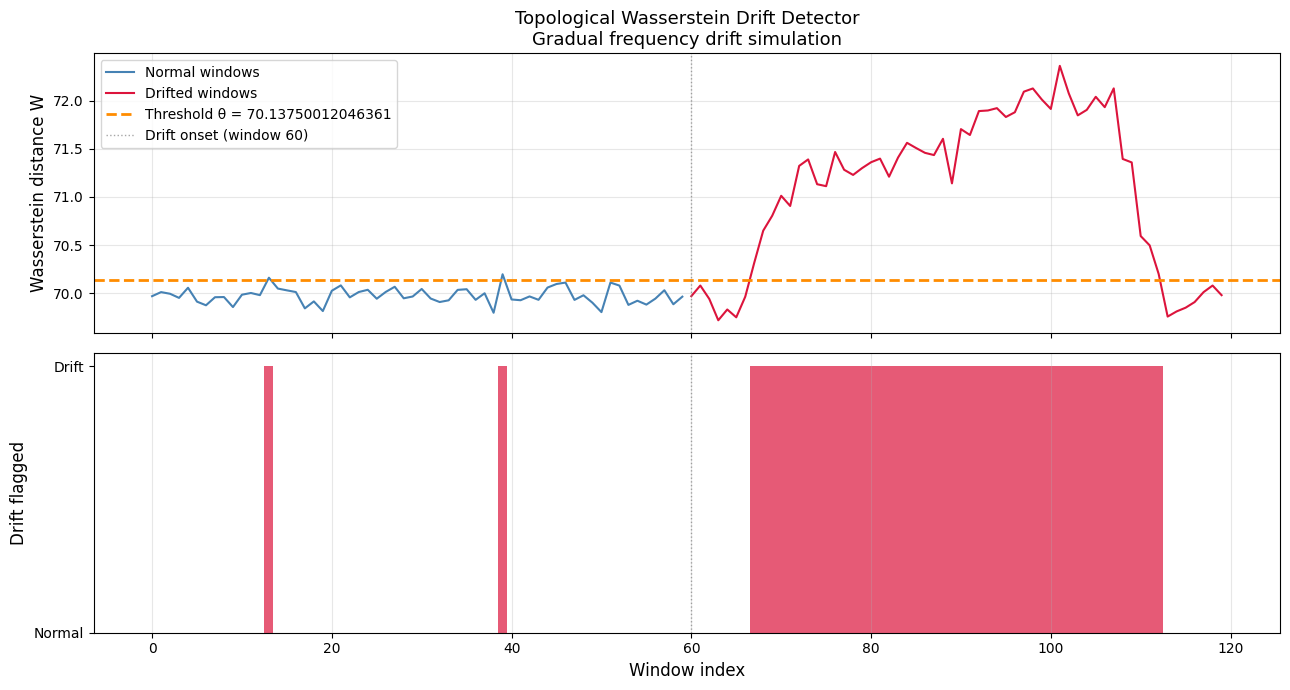

Saved: figures/phase4_drift_detection_curve.png

Calibrating threshold...
Calibrated threshold: 70.1811  (F1=1.0000)
Updated threshold: 70.1811


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

window_idx = np.arange(N_STREAM)

# Top: Wasserstein distance over time
ax1.plot(window_idx[:DRIFT_START],  w_distances[:DRIFT_START],
         color="steelblue", lw=1.5, label="Normal windows")
ax1.plot(window_idx[DRIFT_START:],  w_distances[DRIFT_START:],
         color="crimson",   lw=1.5, label="Drifted windows")
ax1.axhline(drift_det2.threshold, color="darkorange", lw=2, ls="--",
            label=f"Threshold θ = {drift_det2.threshold}")
ax1.axvline(DRIFT_START, color="gray", lw=1, ls=":", alpha=0.7,
            label=f"Drift onset (window {DRIFT_START})")
ax1.set_ylabel("Wasserstein distance W", fontsize=12)
ax1.set_title("Topological Wasserstein Drift Detector\n"
              "Gradual frequency drift simulation", fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom: drift flag (binary)
colors = ["crimson" if f else "steelblue" for f in drift_flags]
ax2.bar(window_idx, drift_flags, color=colors, alpha=0.7, width=1.0)
ax2.axvline(DRIFT_START, color="gray", lw=1, ls=":", alpha=0.7)
ax2.set_xlabel("Window index", fontsize=12)
ax2.set_ylabel("Drift flagged", fontsize=12)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["Normal", "Drift"])
ax2.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/phase4_drift_detection_curve.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/phase4_drift_detection_curve.png")

# ── Calibrate threshold ───────────────────────────────────────────────────────
print("\nCalibrating threshold...")
normal_cal  = make_normal(20, seed=10)
drifted_cal = [np.sin(1.5*t) + np.random.normal(0, 0.02, 500)
               for _ in range(20)]

best_thr = drift_det2.calibrate_threshold(normal_cal, drifted_cal)
print(f"Updated threshold: {drift_det2.threshold:.4f}")

In [12]:
import mlflow
import mlflow.sklearn
import pickle
from pathlib import Path

# ── MLflow setup ──────────────────────────────────────────────────────────────
MLFLOW_TRACKING_URI = "mlruns"
EXPERIMENT_NAME     = "tda-mlops-anomaly-detection"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow version      : {mlflow.__version__}")
print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment          : {EXPERIMENT_NAME}")

# ── Load Phase 3 model + results ─────────────────────────────────────────────
with open("models/isoforest_phase3.pkl", "rb") as f:
    phase3_data = pickle.load(f)

clf_phase3       = phase3_data["clf"]
threshold_phase3 = phase3_data["threshold"]

phase3_metrics = {
    "f1"              : 0.9877,
    "precision"       : 0.9756,
    "recall"          : 1.0000,
    "best_threshold"  : float(threshold_phase3),
    "n_train_windows" : 160,
    "n_test_windows"  : 80,
    "improvement_pct" : 35.2,
}

phase3_params = {
    "n_estimators"  : 200,
    "contamination" : "auto",
    "random_state"  : 42,
    "embed_dim"     : 3,
    "embed_tau"     : 31,
    "n_pixels"      : 20,
    "feature_len"   : 800,
    "window_size"   : 500,
    "anomaly_types" : "phase_break,freq_mod,dual_freq",
    "n_windows"     : 200,
}

# ── Log Phase 3 run ───────────────────────────────────────────────────────────
with mlflow.start_run(run_name="phase3-isoforest-tda") as run:
    mlflow.log_params(phase3_params)
    mlflow.log_metrics(phase3_metrics)
    mlflow.sklearn.log_model(clf_phase3, artifact_path="isoforest_model")

    for fig_path in Path("figures").glob("phase3_*.png"):
        mlflow.log_artifact(str(fig_path), artifact_path="figures")

    mlflow.log_artifact("models/isoforest_phase3.pkl",
                        artifact_path="models")

    run_id = run.info.run_id
    print(f"\n✓ Phase 3 run logged")
    print(f"  Run ID     : {run_id}")
    print(f"  Experiment : {EXPERIMENT_NAME}")
    print(f"  F1         : {phase3_metrics['f1']}")
    print(f"  Improvement: +{phase3_metrics['improvement_pct']}%")

2026/03/15 19:52:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow version      : 3.10.1
MLflow tracking URI : mlruns
Experiment          : tda-mlops-anomaly-detection


2026/03/15 19:52:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✓ Phase 3 run logged
  Run ID     : 5073fca2f78a4bdbadda2d113cb31b0e
  Experiment : tda-mlops-anomaly-detection
  F1         : 0.9877
  Improvement: +35.2%


In [14]:
from sklearn.metrics import f1_score, precision_score, recall_score

drift_params = {
    "homology_dim"     : drift_det2.homology_dim,
    "embed_dim"        : drift_det2.dim,
    "embed_tau"        : drift_det2.tau,
    "threshold"        : drift_det2.threshold,
    "n_reference"      : len(drift_det2.reference_diagrams_),
    "drift_start"      : DRIFT_START,
    "n_stream_windows" : N_STREAM,
    "drift_type"       : "gradual_frequency_increase",
    "freq_range"       : "1.0_to_1.8",
}

true_labels = np.array([0]*DRIFT_START + [1]*(N_STREAM - DRIFT_START))
pred_labels = np.array(drift_flags).astype(int)

drift_metrics = {
    "drift_f1"             : float(f1_score(true_labels, pred_labels,
                                             zero_division=0)),
    "drift_precision"      : float(precision_score(true_labels, pred_labels,
                                                    zero_division=0)),
    "drift_recall"         : float(recall_score(true_labels, pred_labels,
                                                 zero_division=0)),
    "mean_w_normal"        : float(np.mean(w_distances[:DRIFT_START])),
    "mean_w_drifted"       : float(np.mean(w_distances[DRIFT_START:])),
    "w_separation"         : float(np.mean(w_distances[DRIFT_START:])
                                   - np.mean(w_distances[:DRIFT_START])),
    "first_drift_window"   : int(next(
                                 (i for i, f in enumerate(drift_flags) if f),
                                 N_STREAM)),
    "calibrated_threshold" : float(drift_det2.threshold),
}

with mlflow.start_run(run_name="phase4-topological-drift-detector") as run:
    mlflow.log_params(drift_params)
    mlflow.log_metrics(drift_metrics)
    mlflow.log_artifact("figures/phase4_drift_detection_curve.png",
                        artifact_path="figures")

    drift_run_id = run.info.run_id
    print(f"✓ Drift experiment logged")
    print(f"  Run ID           : {drift_run_id}")
    print(f"  Drift F1         : {drift_metrics['drift_f1']:.4f}")
    print(f"  Drift Precision  : {drift_metrics['drift_precision']:.4f}")
    print(f"  Drift Recall     : {drift_metrics['drift_recall']:.4f}")
    print(f"  W separation     : {drift_metrics['w_separation']:.4f}")
    print(f"  First drift at   : window {drift_metrics['first_drift_window']}")

print("\n" + "=" * 50)
print("Day 10 complete — MLflow runs logged")
print("=" * 50)
print(f"  View UI: mlflow ui --backend-store-uri {MLFLOW_TRACKING_URI}")
print(f"  Then open: http://127.0.0.1:5000")

✓ Drift experiment logged
  Run ID           : 72ec35299efd4d05b841c79b817f4b7f
  Drift F1         : 0.8519
  Drift Precision  : 0.9583
  Drift Recall     : 0.7667
  W separation     : 1.1231
  First drift at   : window 13

Day 10 complete — MLflow runs logged
  View UI: mlflow ui --backend-store-uri mlruns
  Then open: http://127.0.0.1:5000
